In [1]:
import numpy as np
import matplotlib.pyplot as plt

from modules import node, system, sensing
from modules import optimization as opt
from configs import config

noise_power = config.NOISE_POWER

In [2]:
tx = node.TX(x=0, y=0, z=10)
rx = node.RX(x=50, y=50, z=1.5)
ris = node.RIS(x=10, y=50, z=2, N=20)
sys = system.System(tx, ris, rx)

is_los = False
N_samples = 3000
n_loop = 5000

In [3]:
def run_benchmark_for_setting(sys, sigma_db, delta_db, n_loop=5000, N_samples=3000, is_los=False):
    """Run all algorithms under one noise/quantization setting."""
    all_born = []
    all_rms = []
    all_rfocus = []
    all_csm = []
    all_perfect = []
    all_gcsm = []

    # BORN
    for i in range(n_loop):
        print("---------------------------")
        print(f"Computing BORN loop {i} for sigma={sigma_db}, delta={delta_db}")
        sys.gen_channels(is_los=is_los)

        X = np.zeros(shape=(sys.ris.N, N_samples))
        y = np.zeros(shape=(N_samples, 1))
        for j in range(N_samples):
            sys.ris.set_random_binary_phase_shifts()
            x = sys.ris.vector_x
            X[:, j] = x.flatten()
            y[j] = sys.cal_snr(sigma_db=sigma_db, delta_db=delta_db) - sys.c_true

        sens = sensing.Sensing(B=1000, N=sys.ris.N)
        M_est, w_est, _ = sens.solve(X=X, y=y, convergence_plot=False)
        M_est_proj = sens.project_to_psd_lowrank(M_est, r=2)
        sys.ris.vector_x = opt.solve_our_optimization(M_est_proj, w_est)
        sys.ris.theta = np.arccos(sys.ris.vector_x)
        born = 10 * np.log10(sys.cal_snr())
        all_born.append(float(born))

    # RMS, RFocus, CSM, Perfect-CSI
    for i in range(n_loop):
        if i % 100 == 0:
            print("Computing loop", i)
        sys.gen_channels(is_los=is_los)

        X = np.zeros(shape=(sys.ris.N, N_samples))
        y = np.zeros(shape=(N_samples, 1))

        for j in range(N_samples):
            sys.ris.set_random_binary_phase_shifts()
            x = sys.ris.vector_x
            X[:, j] = x.flatten()
            y[j] = sys.cal_snr(sigma_db=sigma_db, delta_db=delta_db) - sys.c_true

        sys.ris.vector_x = opt.RMS(X, y)
        all_rms.append(float(10 * np.log10(sys.cal_snr())))

        sys.ris.vector_x = opt.RFocus(X, y)
        all_rfocus.append(float(10 * np.log10(sys.cal_snr())))

        sys.ris.vector_x = opt.CSM(X, y)
        all_csm.append(float(10 * np.log10(sys.cal_snr())))

        sys.ris.theta, sys.ris.vector_x = opt.perfect_csi(h_0=sys.h_0, h_=sys.h)
        all_perfect.append(float(10 * np.log10(sys.cal_snr())))

    # GCSM
    for i in range(n_loop):
        if i % 100 == 0:
            print("Computing GCSM loop", i)
        sys.gen_channels(is_los=is_los)
        sys.run_GCSM(N_samples=N_samples, sigma_db=sigma_db, delta_db=delta_db)
        all_gcsm.append(float(10 * np.log10(sys.cal_snr())))

    return {
        "BORN": np.array(all_born),
        "Optimal": np.array(all_perfect),
        "GCSM": np.array(all_gcsm),
        "CSM": np.array(all_csm),
        "RFocus": np.array(all_rfocus),
        "RMS": np.array(all_rms),
    }


benchmark_5 = run_benchmark_for_setting(sys, sigma_db=2, delta_db=5, n_loop=n_loop, N_samples=N_samples, is_los=is_los)
benchmark_12 = run_benchmark_for_setting(sys, sigma_db=2, delta_db=12, n_loop=n_loop, N_samples=N_samples, is_los=is_los)

---------------------------
Computing BORN loop 0 for sigma=2, delta=5
Variance of the last 5 estimates = 0.006561902610040445
Consider to increase the batch size or number of samples.
---------------------------
Computing BORN loop 1 for sigma=2, delta=5
---------------------------
Computing BORN loop 2 for sigma=2, delta=5
---------------------------
Computing BORN loop 3 for sigma=2, delta=5
---------------------------
Computing BORN loop 4 for sigma=2, delta=5
Variance of the last 5 estimates = 0.003840461356840519
Consider to increase the batch size or number of samples.
---------------------------
Computing BORN loop 5 for sigma=2, delta=5
---------------------------
Computing BORN loop 6 for sigma=2, delta=5
---------------------------
Computing BORN loop 7 for sigma=2, delta=5
Variance of the last 5 estimates = 0.005608782793517336
Consider to increase the batch size or number of samples.
---------------------------
Computing BORN loop 8 for sigma=2, delta=5
Variance of the las

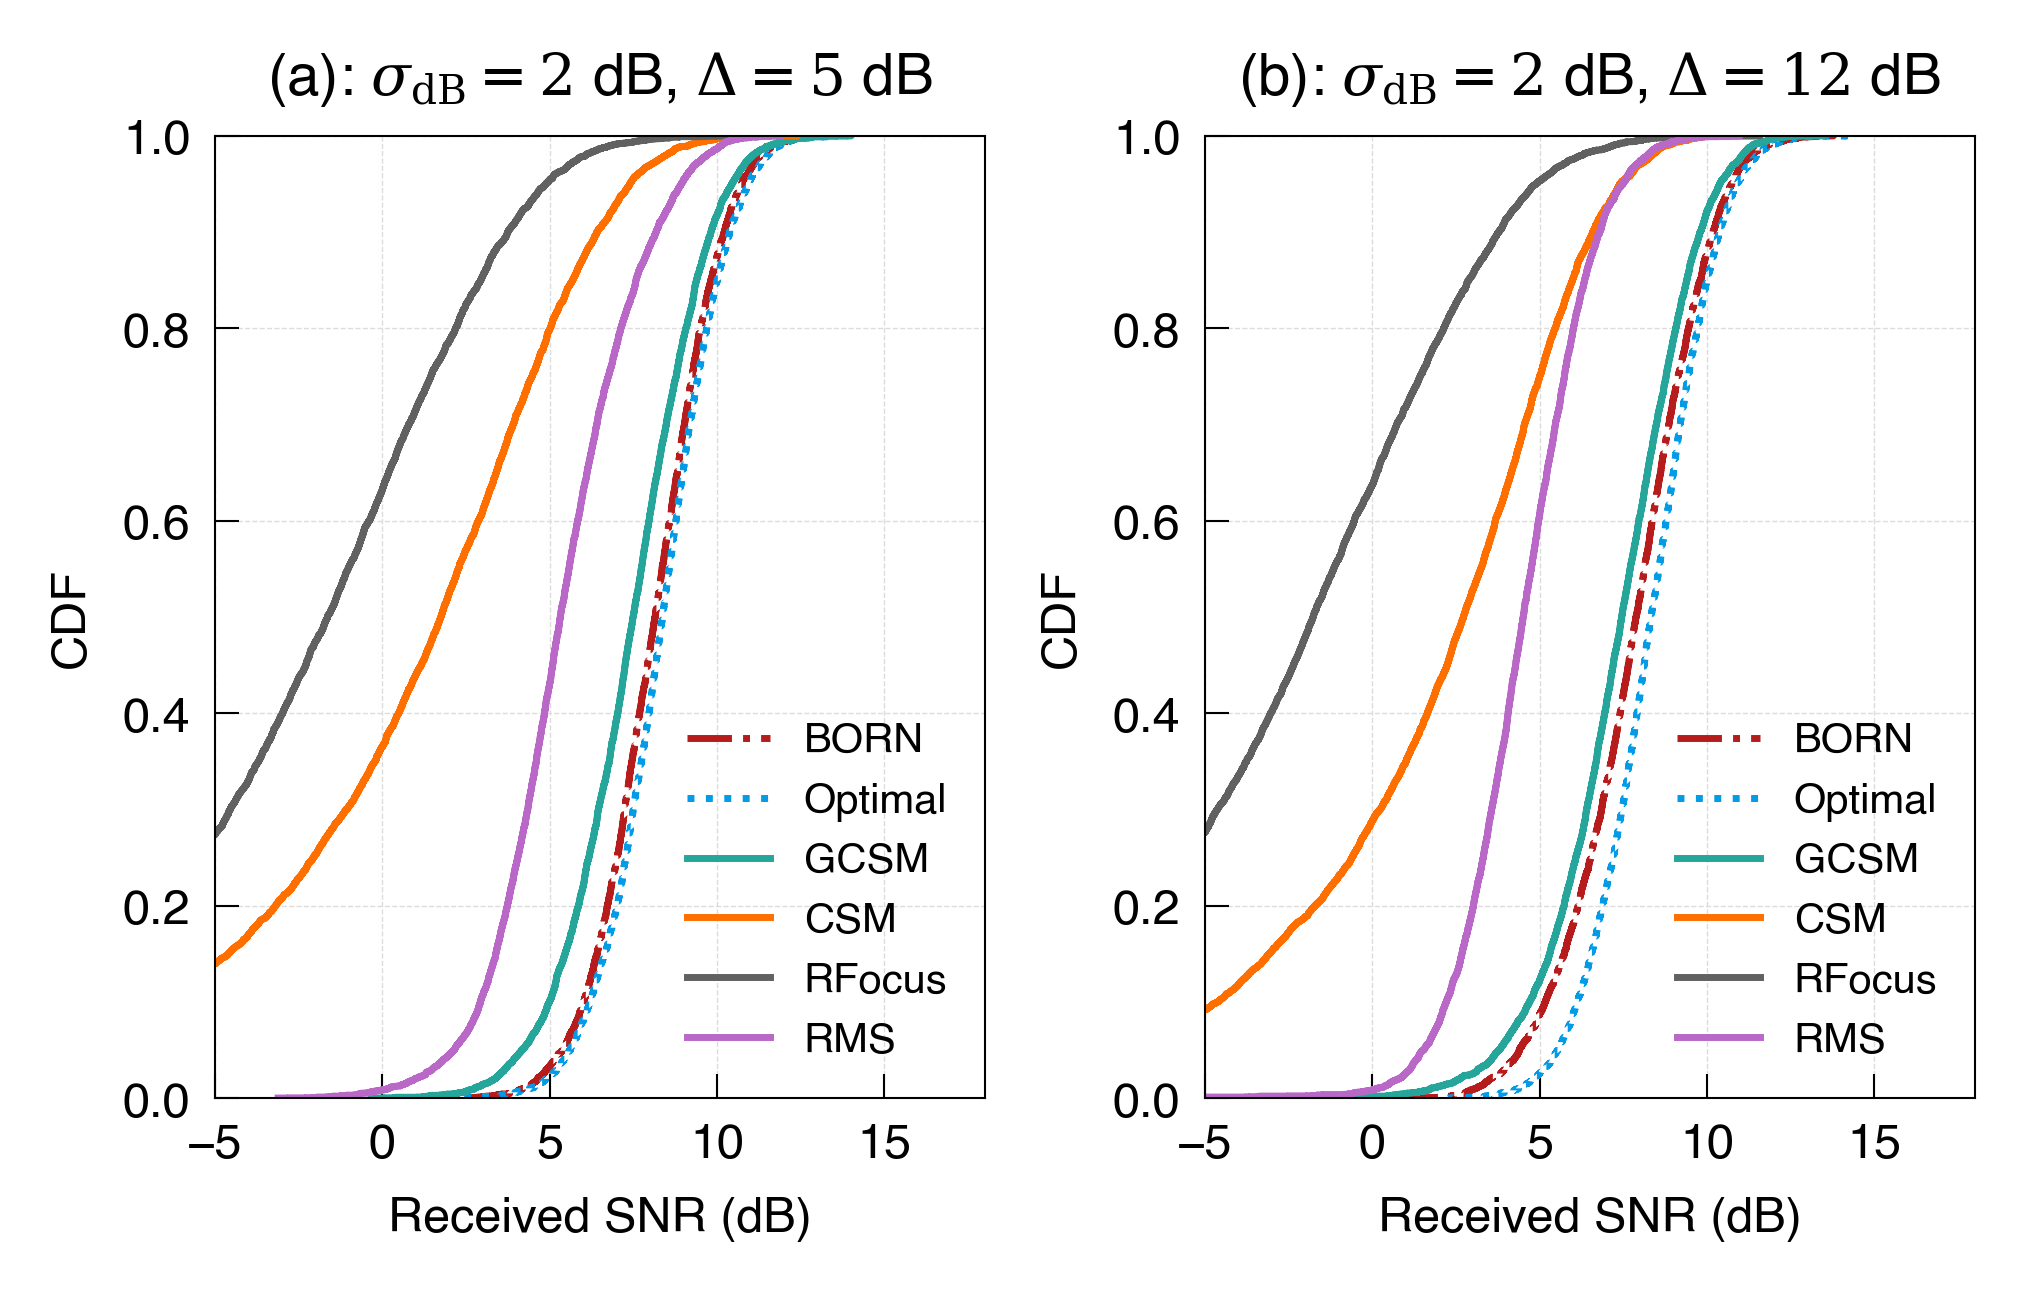

In [14]:
plt.rcParams['font.family'] = 'Helvetica'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'
plt.rcParams['text.usetex'] = False
plt.rcParams['font.size'] = 7
plt.rcParams['legend.fontsize'] = 6
plt.rcParams['xtick.minor.visible'] = False
plt.rcParams['ytick.minor.visible'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.width'] = 0.3
plt.rcParams['ytick.major.width'] = 0.3
plt.rcParams['axes.linewidth'] = 0.3

# Square canvas + rectangular sub-panels
fig = plt.figure(figsize=(5.5, 3.5), dpi=500)

left = 0.10
panel_w = 0.28
gap = 0.08
panel_h = 0.55
y0 = (1 - panel_h) / 2

ax1 = fig.add_axes([left, y0, panel_w, panel_h])
ax2 = fig.add_axes([left + panel_w + gap, y0, panel_w, panel_h])

def _plot_panel(ax, results, title, panel_label):
    colors = ['#B71C1C', '#039BE5', '#26A69A', '#FF6F00', '#616161', '#BA68C8']
    order = [
        ('BORN', '-.', colors[0]),
        ('Optimal', ':', colors[1]),
        ('GCSM', '-', colors[2]),
        ('CSM', '-', colors[3]),
        ('RFocus', '-', colors[4]),
        ('RMS', '-', colors[5]),
    ]

    for label, ls, color in order:
        data = results[label]
        sorted_x = np.sort(data)
        y = np.arange(1, len(data) + 1) / len(data)
        ax.plot(sorted_x, y, drawstyle='steps-post', label=label, linestyle=ls, color=color, linewidth=1.0)

    ax.text(0.03, 0.96, panel_label, transform=ax.transAxes, va='top', ha='left', fontweight='bold', fontsize=8)
    ax.set_title(title)
    ax.set_xlabel('Received SNR (dB)')
    ax.set_ylabel('CDF')
    ax.set_xlim([-5, 18])
    ax.set_ylim([0, 1])
    leg = ax.legend(frameon=False, edgecolor='black', framealpha=0.8)
    leg.get_frame().set_linewidth(0.4)
    ax.grid(color='gainsboro', linestyle='--', linewidth=0.2)
    
_plot_panel(ax1, benchmark_5,  r'(a): $\sigma_{\mathrm{dB}}=2$ dB, $\Delta=5$ dB', '')
_plot_panel(ax2, benchmark_12, r'(b): $\sigma_{\mathrm{dB}}=2$ dB, $\Delta=12$ dB', '')

fig.savefig('fig:noisy_quantized_effect.pdf', dpi=500, bbox_inches='tight', pad_inches=0.05)
plt.show()
